### Introduction to Electrodynamics, Fourth Edition | David J. Griffiths | Solutions and Code by David A. Lee
### Chapter 1: Vector Analysis

# Sketching the vector function  $\mathbf{v} = \dfrac{\hat{\mathbf{r}}}{r^{2}}$

*Griffiths, Introduction to Electrodynamics, Sec. 1.2*

With

$$ r = \sqrt{x^2 + y^2 + z^2}, \qquad \hat{\mathbf{r}} = \frac{x\,\hat{\mathbf{x}} + y\,\hat{\mathbf{y}} + z\,\hat{\mathbf{z}}}{\sqrt{x^2+y^2+z^2}} $$

the field is

$$ \mathbf{v} = \frac{\hat{\mathbf{r}}}{r^{2}} = \frac{x\,\hat{\mathbf{x}} + y\,\hat{\mathbf{y}} + z\,\hat{\mathbf{z}}}{\left(x^2+y^2+z^2\right)^{3/2}}. $$

**Key features to capture in the sketch:**

- It points **radially outward** everywhere ($\parallel \hat{\mathbf{r}}$).
- Its magnitude is $|\mathbf{v}| = 1/r^2$ — it **falls off as the inverse square** of the distance, so arrows are long near the origin and shrink rapidly outward.
- It is **singular at the origin** (blows up there; undefined).
- This is exactly the form of the electric field of a point charge and the gravitational field of a point mass.

Because the magnitude spans many orders of magnitude, a to-scale quiver plot is unreadable. The standard convention (and Griffiths') is to draw **arrows of equal length** and let the magnitude be conveyed by a **colormap** and by drawing arrows on shells.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from vector_field import radial_field, normalize

import sys; sys.path.insert(0, r"C:\Users\david\Documents\physics")
from plotstyle import C, FG, BG, savefig, neon_cmap

%matplotlib inline

# Render ALL figure text with a real LaTeX engine (Computer Modern font).
# Requires a working LaTeX install + dvipng (TeX Live / MiKTeX on PATH).
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{bm}',
    'axes.formatter.use_mathtext': True,
    'figure.dpi': 110,
})

# White background, black text (plotstyle's static theme); the neon lives on
# the vectors, via this colormap and the plotstyle palette C.
CMAP = neon_cmap()

## 1. 2D slice in the $z = 0$ plane

In any plane through the origin the picture is the same by symmetry: arrows point straight out from the center. Color encodes $\log_{10}|\mathbf{v}|$ so the inverse-square falloff is visible even though every arrow is drawn the same length.

C:\Users\david\AppData\Local\Temp\ipykernel_4252\3329990317.py:12: RuntimeWarning: divide by zero encountered in log10
  q = ax.quiver(X, Y, Ux, Uy, np.log10(mag),


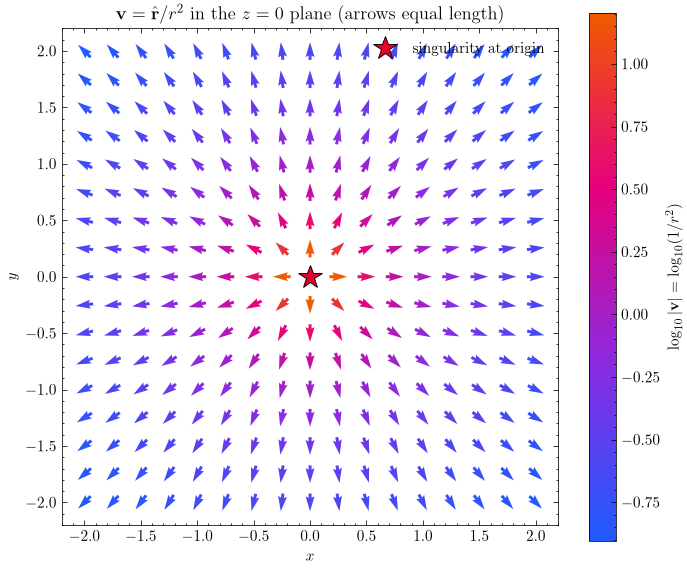

In [2]:
# Grid in the z = 0 plane, skipping the singular origin
n = 17
lim = 2.0
coords = np.linspace(-lim, lim, n)
X, Y = np.meshgrid(coords, coords)
Z = np.zeros_like(X)

Vx, Vy, Vz = radial_field(X, Y, Z)
Ux, Uy, _, mag = normalize(Vx, Vy, Vz)   # equal-length arrows, true magnitude for color

fig, ax = plt.subplots(figsize=(6.5, 6))
q = ax.quiver(X, Y, Ux, Uy, np.log10(mag),
              cmap=CMAP, pivot='mid',
              scale=28, width=0.006)
ax.plot(0, 0, '*', color=C.red, markersize=16,
        markeredgecolor=FG, markeredgewidth=0.6,
        label='singularity at origin')
cbar = fig.colorbar(q, ax=ax, shrink=0.85)
cbar.set_label(r'$\log_{10}|\mathbf{v}| = \log_{10}(1/r^2)$')
ax.set_aspect('equal')
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
ax.set_title(r'$\mathbf{v} = \hat{\mathbf{r}}/r^2$  in the $z=0$ plane (arrows equal length)')
ax.legend(loc='upper right')
plt.tight_layout()
savefig(fig, 'ex1.16_2d_slice.pdf', mirror=False)   # not used by the manual
plt.show()

## 2. True-to-scale arrows (why we normalize)

For comparison, here is the *same* field drawn to scale. The near-origin arrows dominate and everything else vanishes — which is exactly the $1/r^2$ behavior, but it makes a poor sketch.

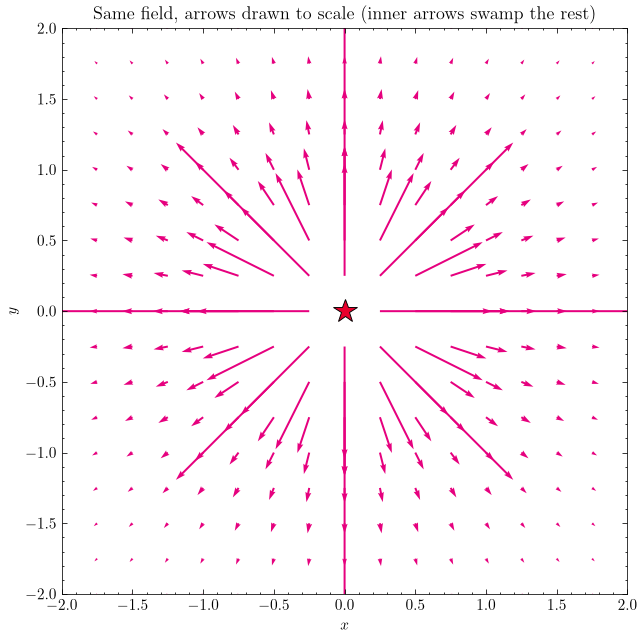

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.quiver(X, Y, Vx, Vy, color=C.magenta, pivot='tail',
          angles='xy', scale_units='xy', scale=6)
ax.plot(0, 0, '*', color=C.red, markersize=16,
        markeredgecolor=FG, markeredgewidth=0.6)
ax.set_aspect('equal')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
ax.set_title('Same field, arrows drawn to scale (inner arrows swamp the rest)')
plt.tight_layout()
savefig(fig, 'ex1.16_to_scale.pdf', mirror=False)   # not used by the manual
plt.show()

## 3. Full 3D sketch

Arrows placed on a 3D grid (equal length), colored by $\log_{10}|\mathbf{v}|$. Every arrow points away from the origin — this is the 3D "hedgehog" of an inverse-square source.

saved ex1.16_3d.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\physics\introelectrodynamics\chap1\sec1.2\ex1.16.pdf


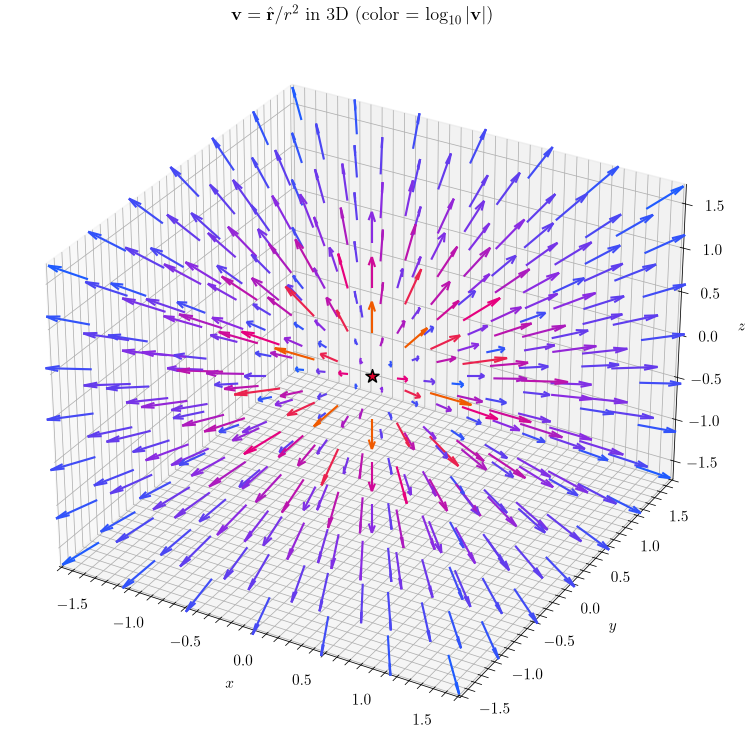

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D projection)

m = 7
g = np.linspace(-1.5, 1.5, m)
X3, Y3, Z3 = np.meshgrid(g, g, g)
# Drop points too close to the origin (singular / huge)
mask = np.sqrt(X3**2 + Y3**2 + Z3**2) > 0.4
X3, Y3, Z3 = X3[mask], Y3[mask], Z3[mask]

Vx3, Vy3, Vz3 = radial_field(X3, Y3, Z3)
Ux3, Uy3, Uz3, mag3 = normalize(Vx3, Vy3, Vz3)

fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection='3d')
logm = np.log10(mag3)
colors = CMAP((logm - logm.min()) / np.ptp(logm))
ax.quiver(X3, Y3, Z3, Ux3, Uy3, Uz3, length=0.35, normalize=True,
          colors=colors, linewidth=1.4)
ax.scatter([0], [0], [0], color=C.red, s=80, marker='*',
           edgecolor=FG, depthshade=False)
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$'); ax.set_zlabel(r'$z$')
ax.set_title(r'$\mathbf{v} = \hat{\mathbf{r}}/r^2$  in 3D  (color = $\log_{10}|\mathbf{v}|$)')
plt.tight_layout()
savefig(fig, 'ex1.16_3d.pdf', linux_name='sec1.2/ex1.16.pdf')   # the manual's name for it
plt.show()

## 4. Magnitude profile: the inverse-square law

A quick sanity check that $|\mathbf{v}| = 1/r^2$ along any ray.

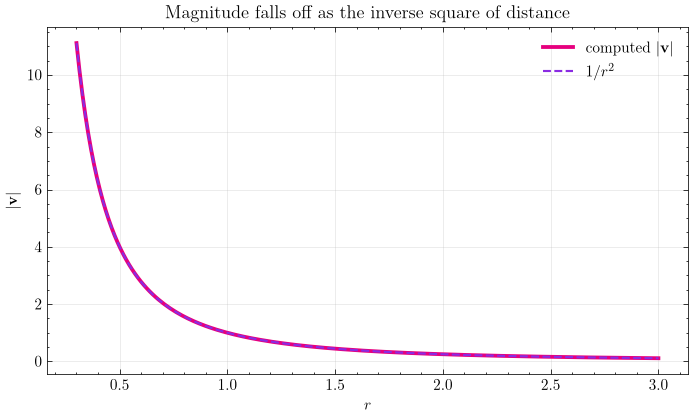

In [5]:
r = np.linspace(0.3, 3.0, 200)
# sample along the x-axis; magnitude is direction-independent
vx, vy, vz = radial_field(r, np.zeros_like(r), np.zeros_like(r))
mag = np.sqrt(vx**2 + vy**2 + vz**2)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(r, mag, lw=2.5, color=C.magenta, label=r'computed $|\mathbf{v}|$')
ax.plot(r, 1/r**2, '--', lw=1.4, color=C.violet, label=r'$1/r^2$')
ax.set_xlabel(r'$r$'); ax.set_ylabel(r'$|\mathbf{v}|$')
ax.set_title('Magnitude falls off as the inverse square of distance')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
savefig(fig, 'ex1.16_magnitude.pdf', mirror=False)   # not used by the manual
plt.show()

## Problem 1.20 — clockwise tangent field on a circle

Draw a circle in the $xy$ plane. At a few representative points draw the vector $\mathbf{v}$ tangent to the circle, pointing in the **clockwise** direction.

A point on the unit circle is $(x, y) = (\cos\theta, \sin\theta)$. The tangent directions are

$$ \text{counterclockwise: } (-\sin\theta,\ \cos\theta) = (-y,\ x), \qquad \text{clockwise: } (\sin\theta,\ -\cos\theta) = (y,\ -x). $$

So the clockwise tangent field is $\;\mathbf{v} = y\,\hat{\mathbf{x}} - x\,\hat{\mathbf{y}}$. Check: at $(1,0)$ it gives $(0,-1)$ — straight down, which is indeed the clockwise direction there.

saved ex1.20_clockwise.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\physics\introelectrodynamics\chap1\sec1.2\ex1.20.pdf


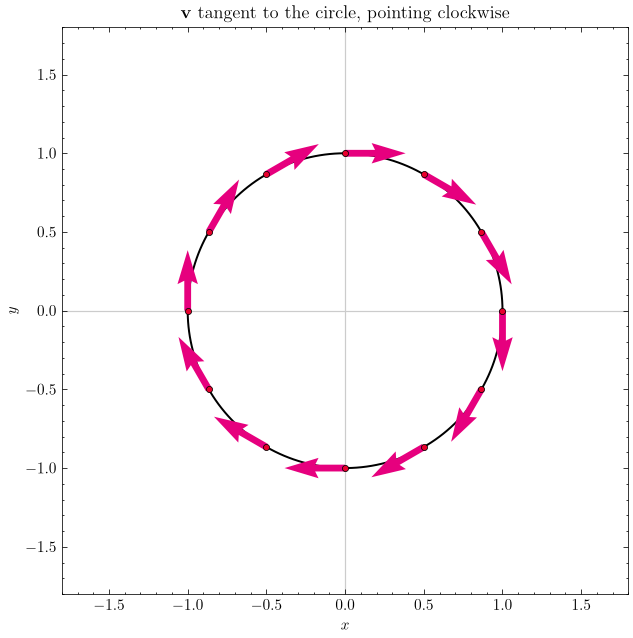

In [6]:
# Unit circle in the xy plane
theta_line = np.linspace(0, 2*np.pi, 400)
xc, yc = np.cos(theta_line), np.sin(theta_line)

# A few representative points around the circle
theta_pts = np.linspace(0, 2*np.pi, 12, endpoint=False)
px, py = np.cos(theta_pts), np.sin(theta_pts)

# Clockwise tangent:  v = (y, -x)   (at (1,0) this is (0,-1), i.e. downward)
vx_t = py
vy_t = -px

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(xc, yc, color=FG, lw=1.3)                       # the circle
ax.quiver(px, py, vx_t, vy_t, color=C.magenta,
          angles='xy', scale_units='xy', scale=2.6,
          width=0.012, pivot='tail', zorder=3)               # tangent vectors
ax.plot(px, py, 'o', color=C.red, markersize=4,
        markeredgecolor=FG, markeredgewidth=0.5, zorder=4)

ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
ax.axhline(0, color='0.8', lw=0.8, zorder=0)
ax.axvline(0, color='0.8', lw=0.8, zorder=0)
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$y$')
ax.set_title(r'$\mathbf{v}$ tangent to the circle, pointing clockwise')
plt.tight_layout()
savefig(fig, 'ex1.20_clockwise.pdf', linux_name='sec1.2/ex1.20.pdf')   # the manual's name for it
plt.show()